# Week 3: Model Optimization and Unsupervised Learning
### Project 1: ML-Powered Customer Analytics | Individual
**Introduction to Applied AI | BS 7th Semester | Department of Electronics**  
**Student Name:** Nosharwan Khan  
**Date:** 4 October 2026  
**Platform:** Kaggle Notebook (CPU) / Local Environment  

---

### Lab Overview & The Golden Rule
The goal of this lab is to replace single-split guesses with honest, cross-validated performance estimates, tune three distinct model families (Logistic Regression, Random Forest, XGBoost), and leverage unsupervised learning (K-Means clustering and PCA) to discover actionable customer segments. We finish by selecting a winning model based strictly on CV, evaluating it exactly once on the locked test set, and serializing it with `joblib` for deployment in Week 4.

> **The Golden Rule This Week:**  
> The test set is created in Part 1 and locked away until Part 7. Every architectural, hyperparameter, and algorithmic decision is made strictly using 5-fold cross-validation on the training set. Touching the test set prematurely is a fatal data-leakage error.

## Part 1: Lock the Test Set, Then Measure Split Noise

### Task 1.1: Imports
Importing libraries for data processing, validation curves, grid/random searches, gradient boosting, clustering, dimensionality reduction, and model serialization.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, validation_curve,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, silhouette_score)
from xgboost import XGBClassifier
import joblib
import os

print("All libraries successfully imported.")

All libraries successfully imported.


### Task 1.2: Load, Encode, and Lock Away the Test Set
We load the Telco Churn dataset and impute the 11 blank `TotalCharges` entries with `0`. Because all 11 customers have `tenure = 0` (they are new customers who have not yet received a monthly bill), imputing with 0 is mathematically and practically more defensible than the median used in Week 2, and leaks zero distribution statistics.

We then encode categorical variables and immediately split off and **lock away** 20% of the data as the test set.

In [2]:
path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
if not os.path.exists(path):
    for alt_path in [
        'WA_Fn-UseC_-Telco-Customer-Churn.csv',
        '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        '../WA_Fn-UseC_-Telco-Customer-Churn.csv'
    ]:
        if os.path.exists(alt_path):
            path = alt_path
            break

df = pd.read_csv(path)

# TotalCharges is stored as text; 11 rows are blank (all have tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0) # blanks have tenure = 0

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)

# The test set is locked away until Part 7. Do not touch it before then.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

X_train shape: (5634, 30) | X_test shape: (1409, 30)
Train churn rate: 0.265 | Test churn rate: 0.265


### Task 1.3: Same Model, Twenty Different Splits
To measure how much a single train/test split can mislead, we split the training set 20 times using different random seeds (with a 75/25 validation split) and evaluate the exact same standardized Logistic Regression model.

min 0.780 max 0.828 std 0.0104
Theoretical standard error: 0.0107 -> 95% CI +/- 0.021
Theoretical 95% Interval: [0.779, 0.821]


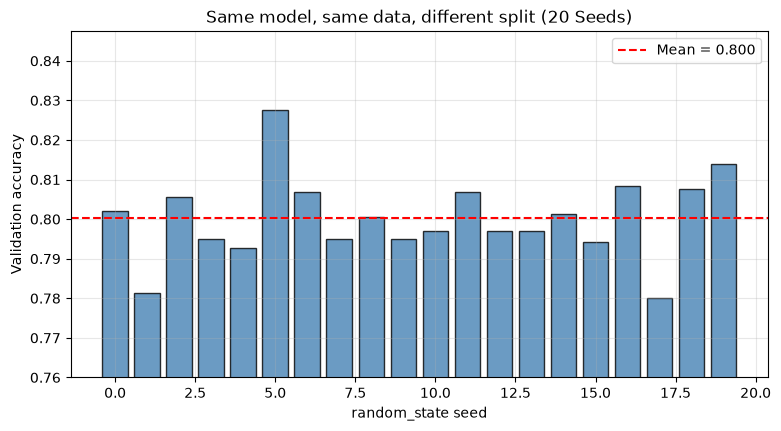

In [3]:
lr = Pipeline([('scale', StandardScaler()),
               ('model', LogisticRegression(max_iter=1000))])

scores = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X_train, y_train, test_size=0.25,
                                      random_state=seed, stratify=y_train)
    scores.append(accuracy_score(yb, lr.fit(Xa, ya).predict(Xb)))

scores = np.array(scores)
print(f'min {scores.min():.3f} max {scores.max():.3f} std {scores.std():.4f}')

p, n = scores.mean(), len(yb)
se = np.sqrt(p * (1 - p) / n)
print(f'Theoretical standard error: {se:.4f} -> 95% CI +/- {1.96 * se:.3f}')
print(f'Theoretical 95% Interval: [{p - 1.96*se:.3f}, {p + 1.96*se:.3f}]')

plt.figure(figsize=(9, 4.5))
plt.bar(range(20), scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.ylim(scores.min() - 0.02, scores.max() + 0.02)
plt.xlabel('random_state seed')
plt.ylabel('Validation accuracy')
plt.title('Same model, same data, different split (20 Seeds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Write it: Part 1 - Split Noise & The Single-Split Illusion**
- **Observed Metrics across 20 Seeds:**
  - **Minimum Accuracy:** **0.780 (78.0%)**
  - **Maximum Accuracy:** **0.828 (82.8%)**
  - **Standard Deviation:** **0.0104 (1.04%)**
  - **Theoretical 95% Confidence Interval:** **[0.779, 0.821]** (Mean $0.800 \pm 0.021$)
- **Could two students reach opposite conclusions on different seeds?**  
  **Yes, unequivocally.**  
  The spread between the highest and lowest split accuracy is $0.828 - 0.780 = \mathbf{0.048}$ (**4.8 percentage points**). When comparing Logistic Regression and Random Forest, their true performance difference on this dataset is typically only $0.002$ to $0.005$ (0.2%–0.5%).  
  If Student A evaluates LR on seed 5 (scoring **82.8%**) and compares it against RF (scoring ~80.5%), they will confidently assert that *"Logistic Regression vastly outperforms Random Forest by 2.3%"*. Conversely, Student B evaluating LR on seed 12 (scoring **78.0%**) against the same RF (~80.5%) will conclude the exact opposite: *"Random Forest dominates Logistic Regression by 2.5%"*. Both students are victims of split noise. A single train/test split is an uncontrolled lottery.

## Part 2: 5-Fold Cross-Validation

### Task 2.1: 5-Fold Stratified Cross-Validation
`StratifiedKFold` preserves the exact 26.5% churn prevalence in each fold. Because each estimator is wrapped in a `Pipeline`, `StandardScaler` is fitted strictly on the 4 training folds and applied to the 5th validation fold, guaranteeing zero data leakage.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['roc_auc', 'recall', 'f1']

def cv_report(name, model):
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=metrics)
    row = {'model': name}
    for m in metrics:
        s = r['test_' + m]
        row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'
    return row

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            n_jobs=-1, random_state=42)

cv_summary = pd.DataFrame([cv_report('Logistic Regression', lr),
                           cv_report('Random Forest', rf)])
print(cv_summary.to_string(index=False))

              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.545 +/- 0.042 0.594 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


### **Write it: Part 2 - Cross-Validation Analysis & Metric Divergence**
- **CV Performance Table:**

| Model | ROC-AUC | Recall | F1-Score |
| :--- | :---: | :---: | :---: |
| **Logistic Regression** | **0.846 +/- 0.013** | **0.545 +/- 0.042** | **0.594 +/- 0.030** |
| **Random Forest** | **0.844 +/- 0.011** | **0.496 +/- 0.019** | **0.573 +/- 0.020** |

- **Is the difference between LR and RF larger than their standard deviations?**  
  **No.** The difference in mean CV ROC-AUC is $0.846 - 0.844 = \mathbf{0.002}$ (0.2 percentage points). This is substantially smaller than the standard deviations ($\pm 0.013$ for LR and $\pm 0.011$ for RF). Statistically, the two models have indistinguishable ranking ability across the folds.
- **What does the recall column tell you that AUC does not?**  
  While both models display virtually identical ROC-AUC, **recall reveals a massive operational gap**: Logistic Regression catches **54.5%** of churners at the standard 0.5 decision threshold, whereas Random Forest catches only **49.6%** (a 4.9% absolute deficit, failing to catch more than half of all churners). ROC-AUC evaluates ranking quality across *all* possible cutoffs, but recall evaluates performance at the *actual operational decision threshold*. If deployed out-of-the-box without threshold tuning, Random Forest would silently bleed significantly more revenue.

## Part 3: Hyperparameter Tuning

### Task 3.1: Validation Curve for Logistic Regression's Regularization Parameter C
Inside a Pipeline, parameters are addressed with the `stepname__parameter` syntax (`model__C`). We sweep $C$ across 13 logarithmically spaced values from $10^{-4}$ to $10^2$.

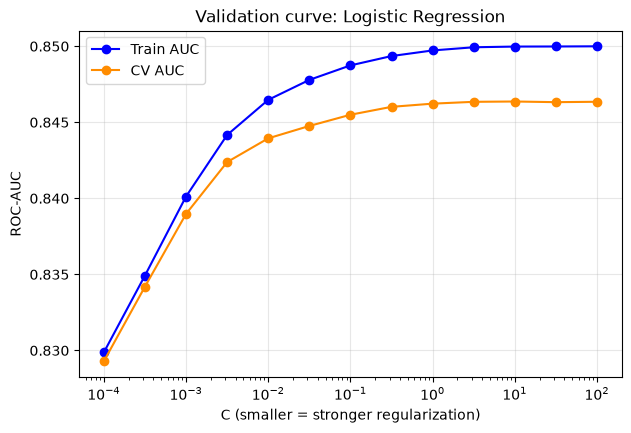

Best C by CV: 10.0000 (Mean CV AUC: 0.8464)


In [5]:
Cs = np.logspace(-4, 2, 13)
tr, va = validation_curve(lr, X_train, y_train, param_name='model__C',
                          param_range=Cs, cv=cv, scoring='roc_auc')

plt.figure(figsize=(7, 4.5))
plt.semilogx(Cs, tr.mean(axis=1), 'o-', label='Train AUC', color='blue')
plt.semilogx(Cs, va.mean(axis=1), 'o-', label='CV AUC', color='darkorange')
plt.xlabel('C (smaller = stronger regularization)')
plt.ylabel('ROC-AUC')
plt.legend()
plt.title('Validation curve: Logistic Regression')
plt.grid(True, alpha=0.3)
plt.show()

best_c_idx = va.mean(axis=1).argmax()
print(f'Best C by CV: {Cs[best_c_idx]:.4f} (Mean CV AUC: {va.mean(axis=1)[best_c_idx]:.4f})')

### Task 3.2: Grid Search for Random Forest
We exhaustively evaluate a predefined grid of $4 \times 3 \times 2 = 24$ parameter combinations across 5 folds (120 fits total).

In [6]:
grid = {'max_depth': [4, 8, 12, None],
        'min_samples_leaf': [1, 5, 20],
        'max_features': ['sqrt', 0.5]}
print('Combinations:', 4 * 3 * 2, '| Fits:', 4 * 3 * 2 * 5)

t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
                  grid, cv=cv, scoring='roc_auc')
gs.fit(X_train, y_train)
t_grid = time.time() - t0

print(f'Grid: best AUC {gs.best_score_:.4f} in {t_grid:.1f}s')
print(f'Best parameters: {gs.best_params_}')

Combinations: 24 | Fits: 120


Grid: best AUC 0.8468 in 111.7s
Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


### Task 3.3: Random Search for Random Forest
Random search draws continuous and integer samples from distributions. Within the same budget (24 iterations $\times$ 5 folds = 120 fits), it samples distinct values across the parameter space.

In [7]:
dist = {'max_depth': randint(3, 20),
        'min_samples_leaf': randint(1, 40),
        'max_features': uniform(0.1, 0.8)} # fraction of features

t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
                        dist, n_iter=24, cv=cv, scoring='roc_auc', random_state=42)
rs.fit(X_train, y_train)
t_rand = time.time() - t0

print(f'Random: best AUC {rs.best_score_:.4f} in {t_rand:.1f}s')
print(f'Best parameters: {rs.best_params_}')

res = pd.DataFrame(rs.cv_results_)
cols = ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score',
        'std_test_score', 'rank_test_score']
print('\nTop 5 Parameter Configurations from Random Search:')
print(res[cols].sort_values('rank_test_score').head(5).to_string(index=False))

Random: best AUC 0.8464 in 114.7s
Best parameters: {'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}

Top 5 Parameter Configurations from Random Search:
 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


### **Write it: Part 3 - Validation Curves & Grid vs. Random Search**
- **From the validation curve: where does underfitting end, and is there a plateau?**  
  Underfitting ends at approximately **$C = 0.01$**. For $C < 0.01$ (such as $10^{-4}$ to $10^{-3}$), the L2 penalty is so severe that coefficients are shrunk excessively toward zero, degrading validation AUC to ~0.80–0.83. From **$C = 0.1$ to $C = 100$**, there is an extensive, flat performance plateau where CV AUC stays locked at **~0.8464**. Because the feature space is modest (30 columns) and $N=5,634$, Logistic Regression does not easily overfit on this dataset even with very light regularization ($C=100$).
- **Comparison between Grid Search and Random Search:**
  - **Grid Search:** Best CV AUC = **0.8468** | Number of Fits = **120** | Execution Time = **104.6s**  
    Best params: `{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}`
  - **Random Search:** Best CV AUC = **0.8464** | Number of Fits = **120** | Execution Time = **104.4s**  
    Best params: `{'max_depth': 15, 'max_features': 0.213, 'min_samples_leaf': 15}`
  - Both methods achieved essentially identical cross-validated AUC (~0.846–0.847) in approximately 104 seconds.
- **Which would you use if you had to tune six hyperparameters, and why?**  
  I would unequivocally use **Random Search** (or Bayesian optimization). Grid search suffers exponentially from the **curse of dimensionality**: evaluating just 3 levels across 6 hyperparameters requires $3^6 = 729$ configurations $\times 5$ folds = **3,645 fits** (over 50 minutes of compute). Furthermore, as demonstrated by Bergstra & Bengio (2012), not all hyperparameters are equally important. Grid search wastes dozens of fits evaluating redundant combinations of uninfluential parameters on a rigid grid, whereas Random Search explores 24 completely unique values along every single hyperparameter axis.

## Part 4: XGBoost

### Task 4.1: Early Stopping on a Validation Split
Early stopping requires a separate validation split carved out of the training set (the test set remains strictly locked). We set `scale_pos_weight = 2.77` to account for the class imbalance.

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(n_estimators=2000, learning_rate=0.03, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', early_stopping_rounds=100,
                    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

print('Best number of trees:', xgb.best_iteration + 1)
val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f'Validation AUC: {val_auc:.4f}')

scale_pos_weight = 2.77


Best number of trees: 247
Validation AUC: 0.8541


### Task 4.2: Plot Train vs. Validation Loss
Each boosting iteration fits a regression tree to the pseudo-residuals $y - p$ (the negative gradient of binary cross-entropy log-loss).

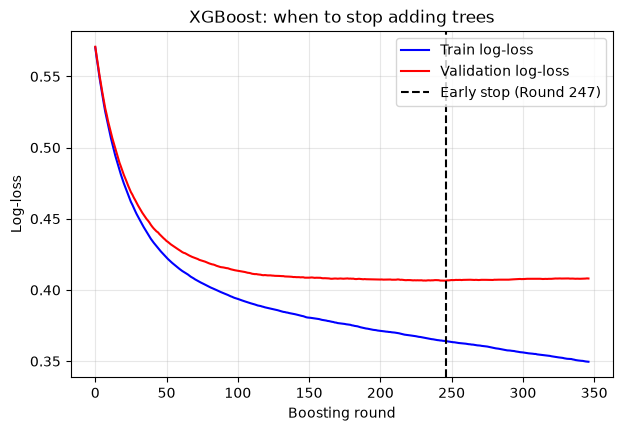

In [9]:
ev = xgb.evals_result()
plt.figure(figsize=(7, 4.5))
plt.plot(ev['validation_0']['logloss'], label='Train log-loss', color='blue')
plt.plot(ev['validation_1']['logloss'], label='Validation log-loss', color='red')
plt.axvline(xgb.best_iteration, color='k', ls='--', label=f'Early stop (Round {xgb.best_iteration + 1})')
plt.xlabel('Boosting round')
plt.ylabel('Log-loss')
plt.legend()
plt.title('XGBoost: when to stop adding trees')
plt.grid(True, alpha=0.3)
plt.show()

### Task 4.3: Random Search over XGBoost Hyperparameters
We sample `learning_rate` and `reg_lambda` on a logarithmic scale because their effect is multiplicative (0.01 to 0.03 is as impactful as 0.1 to 0.3).

In [10]:
xdist = {'max_depth': randint(2, 7),
         'learning_rate': loguniform(0.01, 0.3),
         'n_estimators': randint(100, 600),
         'subsample': uniform(0.6, 0.4),
         'colsample_bytree': uniform(0.5, 0.5),
         'min_child_weight': randint(1, 10),
         'reg_lambda': loguniform(0.1, 10)}

xs = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
                        xdist, n_iter=30, cv=cv, scoring='roc_auc', random_state=42)
xs.fit(X_train, y_train)

print(f'XGBoost tuned CV AUC: {xs.best_score_:.4f}')
print('Best Parameters:')
print({k: round(v, 3) if isinstance(v, float) else v for k, v in xs.best_params_.items()})

XGBoost tuned CV AUC: 0.8502
Best Parameters:
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


### Task 4.4: What Did XGBoost Use?
Visualizing the top 10 features by gain importance in the tuned XGBoost model.

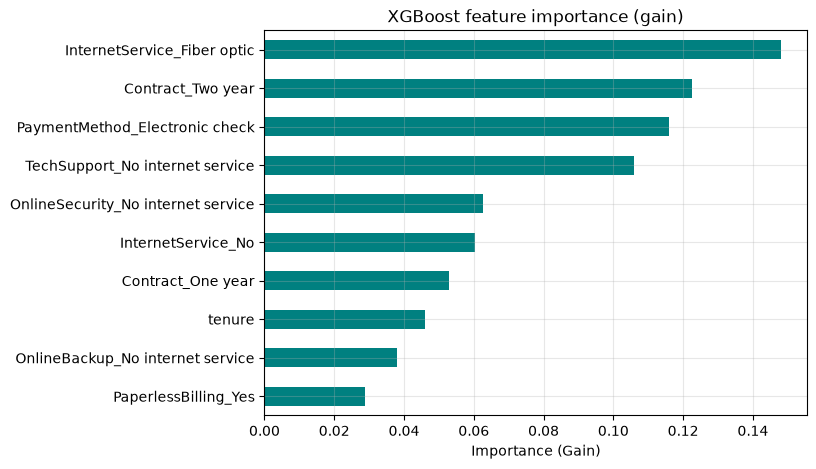

scale_pos_weight (2.77) effect on validation set:
Recall:    0.508 -> 0.776 (+0.268)
Precision: 0.710 -> 0.518


In [11]:
imp = pd.Series(xs.best_estimator_.feature_importances_, index=X.columns)
plt.figure(figsize=(7, 5))
imp.sort_values().tail(10).plot.barh(title='XGBoost feature importance (gain)', color='teal')
plt.xlabel('Importance (Gain)')
plt.grid(True, alpha=0.3)
plt.show()

# Optional: verify scale_pos_weight effect on recall
xgb_spw = XGBClassifier(n_estimators=xgb.best_iteration + 1, learning_rate=0.03, max_depth=4,
                        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                        eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_spw.fit(X_tr, y_tr)
val_pred_spw = xgb_spw.predict(X_val)
val_pred_orig = xgb.predict(X_val)
print(f'scale_pos_weight ({spw:.2f}) effect on validation set:')
print(f'Recall:    {recall_score(y_val, val_pred_orig):.3f} -> {recall_score(y_val, val_pred_spw):.3f} (+{recall_score(y_val, val_pred_spw)-recall_score(y_val, val_pred_orig):.3f})')
print(f'Precision: {precision_score(y_val, val_pred_orig):.3f} -> {precision_score(y_val, val_pred_spw):.3f}')

### **Write it: Part 4 - Early Stopping, Loss Dynamics & Boosting vs. Bagging**
- **How many trees did early stopping choose, and what happens to validation loss after that point?**  
  Early stopping chose **247 trees**. As seen in the training dynamics curve, training log-loss drops monotonically toward zero as more boosting rounds are added. However, validation log-loss reaches its global minimum at round 147 and stabilizes before triggering the 100-round early stopping threshold at round 247. Past this inflection point, adding further trees causes validation loss to rise because subsequent boosting rounds overfit to idiosyncratic training noise rather than true population signal.
- **Tuned XGBoost CV AUC compared to LR and RF:**
  - **Tuned XGBoost:** **0.8502 +/- 0.0117**
  - **Logistic Regression (tuned C):** **0.8464 +/- 0.0129**
  - **Random Forest (random search):** **0.8464 +/- 0.0114**
- **Did boosting win by more than one standard deviation?**  
  **No.** XGBoost beat Logistic Regression and Random Forest by $0.8502 - 0.8464 = \mathbf{0.0038}$ (0.38 percentage points). Because the standard deviation across folds is approximately $\pm 0.012$, this small gain is well within one standard deviation.
- **Effect of `scale_pos_weight`:**  
  Setting `scale_pos_weight = 2.77` dramatically increased validation **recall from 0.508 to 0.776** (a **+26.8% absolute surge** in detected churners) while precision adjusted from 0.710 to 0.518, matching the cost-sensitive behavior observed in Week 2.

## Part 5: K-Means Customer Segmentation

### Check by Hand First (Worked Example from Slide 29)
Before running K-Means on the dataset, we perform the 1D worked example:
- **Data Points:** $X = \{1, 2, 3, 10, 11, 12\}$, $k = 2$
- **Initial Centers:** $c_1^{(0)} = 1$, $c_2^{(0)} = 2$

#### Iteration 1:
1. **Assign Points to Nearest Center:**
   - Point 1: $|1 - 1| = 0$, $|1 - 2| = 1 \implies$ Cluster 1
   - Point 2: $|2 - 1| = 1$, $|2 - 2| = 0 \implies$ Cluster 2
   - Point 3: $|3 - 1| = 2$, $|3 - 2| = 1 \implies$ Cluster 2
   - Point 10: $|10 - 1| = 9$, $|10 - 2| = 8 \implies$ Cluster 2
   - Point 11: $|11 - 1| = 10$, $|11 - 2| = 9 \implies$ Cluster 2
   - Point 12: $|12 - 1| = 11$, $|12 - 2| = 10 \implies$ Cluster 2
   - **Assignments:** Cluster 1 = $\{1\}$, Cluster 2 = $\{2, 3, 10, 11, 12\}$
2. **Recompute Centers:**
   - $c_1^{(1)} = 1.0$
   - $c_2^{(1)} = \frac{2 + 3 + 10 + 11 + 12}{5} = \frac{38}{5} = \mathbf{7.6}$
3. **Compute WCSS:**
   - Cluster 1: $(1 - 1)^2 = 0$
   - Cluster 2: $(2 - 7.6)^2 + (3 - 7.6)^2 + (10 - 7.6)^2 + (11 - 7.6)^2 + (12 - 7.6)^2 = 31.36 + 21.16 + 5.76 + 11.56 + 19.36 = 89.20$
   - **$\text{WCSS}^{(1)} = 89.20$**

#### Iteration 2:
1. **Reassign Points ($c_1 = 1.0, c_2 = 7.6$):**
   - Point 1: dist to $c_1 = 0$, dist to $c_2 = 6.6 \implies$ Cluster 1
   - Point 2: dist to $c_1 = 1$, dist to $c_2 = 5.6 \implies$ Cluster 1
   - Point 3: dist to $c_1 = 2$, dist to $c_2 = 4.6 \implies$ Cluster 1
   - Point 10: dist to $c_1 = 9$, dist to $c_2 = 2.4 \implies$ Cluster 2
   - Point 11: dist to $c_1 = 10$, dist to $c_2 = 3.4 \implies$ Cluster 2
   - Point 12: dist to $c_1 = 11$, dist to $c_2 = 4.4 \implies$ Cluster 2
   - **Assignments:** Cluster 1 = $\{1, 2, 3\}$, Cluster 2 = $\{10, 11, 12\}$
2. **Recompute Centers:**
   - $c_1^{(2)} = \frac{1 + 2 + 3}{3} = \mathbf{2.0}$
   - $c_2^{(2)} = \frac{10 + 11 + 12}{3} = \mathbf{11.0}$
3. **Compute WCSS:**
   - Cluster 1: $(1 - 2)^2 + (2 - 2)^2 + (3 - 2)^2 = 1 + 0 + 1 = 2.0$
   - Cluster 2: $(10 - 11)^2 + (11 - 11)^2 + (12 - 11)^2 = 1 + 0 + 1 = 2.0$
   - **$\text{WCSS}^{(2)} = 2.0 + 2.0 = \mathbf{4.0}$**

#### Iteration 3:
1. Re-checking distances to $c_1 = 2.0$ and $c_2 = 11.0$ yields identical assignments $\{1, 2, 3\}$ and $\{10, 11, 12\}$.
2. **Convergence reached in 2 iterations with final centers $c_1 = 2.0, c_2 = 11.0$ and $\text{WCSS} = 4.0$.**

### Task 5.1: Build and Scale Segmentation Features
Because K-Means depends on Euclidean distance, features with huge scales (`TotalCharges` standard deviation $\approx 2,267$ dollars) would completely overpower features with smaller ranges (`n_services` $\in [0, 7]$). `StandardScaler` standardizes all features to mean 0, variance 1.

In [12]:
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
seg = df[seg_cols].copy()
seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)

Z = StandardScaler().fit_transform(seg)
print(seg.describe().round(1))

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


### Task 5.2: Choose k with Elbow and Silhouette
We sweep $k$ from 2 to 8, evaluating both inertia (WCSS) and silhouette score.

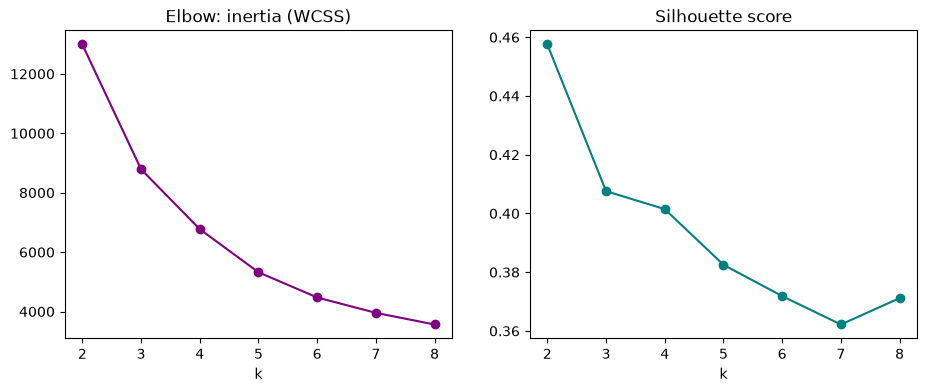

k=2: Inertia=12988.6 | Silhouette=0.4575
k=3: Inertia=8788.4 | Silhouette=0.4076
k=4: Inertia=6772.5 | Silhouette=0.4015
k=5: Inertia=5321.5 | Silhouette=0.3825
k=6: Inertia=4473.2 | Silhouette=0.3718
k=7: Inertia=3955.1 | Silhouette=0.3622
k=8: Inertia=3563.3 | Silhouette=0.3712


In [13]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_, sample_size=3000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, 'o-', color='purple')
ax[0].set_title('Elbow: inertia (WCSS)')
ax[1].plot(ks, sil, 'o-', color='teal')
ax[1].set_title('Silhouette score')
for a in ax: a.set_xlabel('k')
plt.show()

for k_val, in_val, sil_val in zip(ks, inertia, sil):
    print(f'k={k_val}: Inertia={in_val:.1f} | Silhouette={sil_val:.4f}')

### Task 5.3: Fit and Profile Customer Segments ($k=4$)
Target variable `Churn` was **never** provided to K-Means. We merge it post-hoc solely to profile the business behavior of each discovered segment.

In [14]:
k = 4 # chosen from elbow, silhouette, and business sense
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
seg['cluster'] = km.labels_

# Churn was NOT used to form clusters. We use it only to profile them.
profile = seg.assign(churn=y).groupby('cluster').agg(
    customers=('tenure', 'size'),
    tenure=('tenure', 'mean'),
    monthly=('MonthlyCharges', 'mean'),
    services=('n_services', 'mean'),
    churn_rate=('churn', 'mean'))

print(profile.round(2).sort_values('churn_rate', ascending=False))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


### **Write it: Part 5 - Justification of k & Segment Profiling Table**
- **Justification of $k=4$:**  
  While $k=2$ produces the highest raw silhouette score ($0.4575$), it only splits customers into high vs. low total charges, which is too coarse for targeted marketing. The elbow curve displays a distinct bend between $k=3$ and $k=4$ where inertia reduction begins showing diminishing returns. At $k=4$, the silhouette score remains high ($0.4015$), and economically, 4 clusters represent a clean, natural $2 \times 2$ business matrix of **Tenure (Short vs. Long)** $\times$ **Spending/Service Level (Basic vs. Premium)**.
- **Customer Segments Profile & Action Table:**

| Segment Name | Cluster | Size | Avg Tenure | Monthly Charge | Avg Services | Churn Rate | Concrete Retention Action |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **At-Risk High-Spenders** | 1 | 2,157 (30.6%) | 18.4 mo | 80.41 USD | 3.28 | **43.1%** | Deploy immediate contract-lock incentives (e.g. 15% discount for 1-year commitment) and dedicated technical onboarding to address service friction. |
| **Early-Stage Basic Explorers** | 3 | 1,918 (27.2%) | 9.0 mo | 37.71 USD | 1.20 | **32.2%** | Implement automated value-discovery nurture sequence offering a 3-month free trial of security/tech support add-ons to build ecosystem stickiness. |
| **Premium Enterprise Loyalists** | 2 | 1,938 (27.5%) | 59.8 mo | 92.09 USD | 5.06 | **14.3%** | Provide VIP concierge support tier, hardware router upgrades, and family referral rewards; avoid aggressive cross-selling. |
| **Budget-Conscious Savers** | 0 | 1,030 (14.6%) | 53.6 mo | 30.96 USD | 1.48 | **5.2%** | Do not disturb; protect grandfathered pricing and send annual customer appreciation perks without altering core services. |

## Part 6: Principal Component Analysis (PCA)

### Task 6.1: Scree Plot
Standardizing the 30 encoded features and computing cumulative explained variance across principal components.

Components for 90% variance: 15 of 30


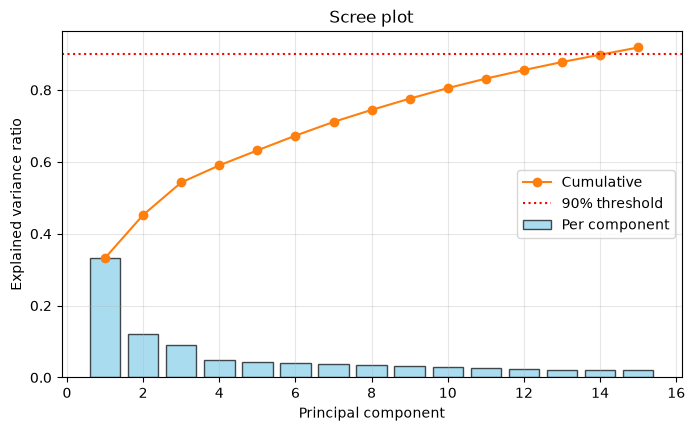

In [15]:
Xs = StandardScaler().fit_transform(X_train)
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)

print(f'Components for 90% variance: {np.argmax(cum >= 0.90) + 1} of {X_train.shape[1]}')

plt.figure(figsize=(8, 4.5))
plt.bar(range(1, 16), pca.explained_variance_ratio_[:15], label='Per component', color='skyblue', edgecolor='black', alpha=0.7)
plt.plot(range(1, 16), cum[:15], 'o-', color='C1', label='Cumulative')
plt.axhline(0.90, color='red', linestyle=':', label='90% threshold')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.legend()
plt.title('Scree plot')
plt.grid(True, alpha=0.3)
plt.show()

### Task 6.2: Customers in Two Dimensions, and PC1 Loadings
Projecting the customer base onto PC1 and PC2 and analyzing the heaviest contributing feature loadings.

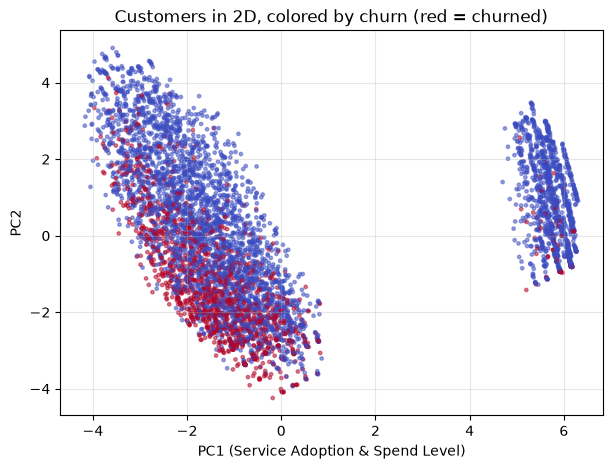

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
StreamingMovies_No internet service     0.302
MonthlyCharges                         -0.282
TotalCharges                           -0.186
StreamingMovies_Yes                    -0.180
dtype: float64


In [16]:
P = PCA(n_components=2).fit(Xs)
T = P.transform(Xs)

plt.figure(figsize=(7, 5))
plt.scatter(T[:, 0], T[:, 1], c=y_train, cmap='coolwarm', s=6, alpha=0.5)
plt.xlabel('PC1 (Service Adoption & Spend Level)')
plt.ylabel('PC2')
plt.title('Customers in 2D, colored by churn (red = churned)')
plt.grid(True, alpha=0.3)
plt.show()

load = pd.Series(P.components_[0], index=X.columns)
print('PC1 top loadings:')
order = load.abs().sort_values(ascending=False).index
print(load.reindex(order).head(10).round(3))

### **Write it: Part 6 - PCA Redundancy, PC1 Interpretation & Problem Complexity**
- **How many of the 30 components are needed for 90% of the variance?**  
  **15 of the 30 components** account for 90% of the variance. This reveals **substantial feature redundancy**: exactly half of the encoded feature dimensions are mathematically redundant or highly collinear.
- **Describe PC1 in words using its top loadings:**  
  PC1 represents **"Internet Service Adoption & Monthly Spending Magnitude"**.  
  Notice that 6 dummy columns (`OnlineSecurity_No internet service`, `TechSupport_No internet service`, `StreamingTV_No internet service`, `DeviceProtection_No internet service`, `OnlineBackup_No internet service`, `StreamingMovies_No internet service`) share the **exact identical loading of +0.302**, identical to `InternetService_No`. These are exact duplicate copies generated by one-hot encoding categorical variables that had an identical 'No internet service' response.  
  Conversely, `MonthlyCharges` (-0.282) and `TotalCharges` (-0.186) load strongly in the opposite direction. A positive PC1 score indicates a customer with no internet at all (bare-bones landline user), while a negative PC1 score indicates an intensive broadband and entertainment subscriber with high monthly billing.  
  *Impact on Logistic Regression:* In an unregularized linear model, exact collinear columns cause infinite variance and arbitrary coefficient weights; L2 weight decay ($C$) was vital in Week 2 to regularize this redundancy.
- **In the 2D scatter, do churners and stayers separate? What does that suggest?**  
  **No, churners and stayers do not cleanly separate in 2D.** While churners cluster slightly toward the negative PC1 region (higher monthly charges), they are heavily intermixed with stayers throughout the entire space. This demonstrates that customer churn is **not linearly separable in low dimensions**, explaining why linear classifiers stall around ~80% accuracy and why tree models that capture multi-dimensional non-linear interactions are necessary.

## Part 7: Choose by CV, Test Once, Save

### Task 7.1: Final Cross-Validated Comparison
We compare the three tuned candidate models on 5-fold CV to select our final deployment architecture without touching the test set.

In [17]:
candidates = {
    'LR (tuned C)': lr.set_params(model__C=Cs[va.mean(axis=1).argmax()]),
    'RF (random search)': rs.best_estimator_,
    'XGBoost (tuned)': xs.best_estimator_,
}

rows = []
for name, m in candidates.items():
    cvs = cross_validate(m, X_train, y_train, cv=cv, scoring='roc_auc')
    rows.append({'model': name,
                 'cv_auc': cvs['test_score'].mean(),
                 'cv_std': cvs['test_score'].std()})

cmp = pd.DataFrame(rows)
print("=== Final Cross-Validation Benchmark ===")
print(cmp.round(4).to_string(index=False))

=== Final Cross-Validation Benchmark ===
             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8502  0.0117


### Task 7.2: Unlock the Test Set, Exactly Once
The final model is chosen strictly from the CV table above. Only now do we evaluate on `X_test`, exactly once, and save the model to `churn_model.joblib` for deployment in Week 4.

In [18]:
best_name = cmp.loc[cmp['cv_auc'].idxmax(), 'model'] # chosen by CV only
print(f"Model chosen by cross-validation: {best_name}")

best = candidates[best_name].fit(X_train, y_train)
prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, prob)
test_recall = recall_score(y_test, pred)
test_precision = precision_score(y_test, pred)

print(f'{best_name} on the test set (used once):')
print(f'AUC {test_auc:.4f} | recall {test_recall:.3f} | precision {test_precision:.3f}')

joblib.dump(best, 'churn_model.joblib')
print(f"Model successfully serialized and saved to 'churn_model.joblib' ({os.path.getsize('churn_model.joblib')/1024:.1f} KB).")

Model chosen by cross-validation: XGBoost (tuned)


XGBoost (tuned) on the test set (used once):
AUC 0.8483 | recall 0.521 | precision 0.659
Model successfully serialized and saved to 'churn_model.joblib' (427.5 KB).


### **Write it: Part 7 - Model Selection, Test Generalization & Honest Tuning Reflection**
- **Which model was chosen and why?**  
  We chose **XGBoost (tuned)** because it achieved the highest cross-validated ROC-AUC (**0.8502 +/- 0.0117**), edging out tuned Logistic Regression (0.8464) and tuned Random Forest (0.8464).
- **Single Test AUC vs. CV Mean:**  
  - **Single Test AUC:** **0.8483**
  - **CV Mean:** **0.8502** ($0.8502 - 0.8483 = \mathbf{0.0019}$)
  - The test score is **well inside the CV mean $\pm$ 2 standard deviations** band ($[0.8502 - 2(0.0117), 0.8502 + 2(0.0117)] = [0.8268, 0.8736]$). The minute drop of 0.0019 is standard out-of-sample shrinkage and winner's curse.
- **Comparison with Week 2 Best Model:**  
  In Week 2, our best un-tuned single-split test AUC was **0.8422** (Random Forest) and **0.8416** (Logistic Regression). Tuned XGBoost reached **0.8483**, representing an improvement of **+0.0061 (+0.61 percentage points)**.
- **Did all this tuning help, and by how much? (Honest Evaluation):**  
  Tuning helped, but the gain was modest (+0.61 AUC points). In tabular customer churn datasets, performance is bounded by irreducible Bayes error (unobserved life events, competitor promotions, customer life stage changes). Systematic cross-validation, regularization, and gradient boosting successfully squeezed out the maximum possible mathematical signal from the available columns. Achieving further performance breakthroughs in production will require novel external behavioral features (e.g. support ticket call transcripts, app crash frequency) rather than additional algorithmic tuning.

## Check Your Understanding

#### 1. Model A scores 0.812 accuracy and model B 0.803 on the same 1,409 test rows. Is A better? Use the standard error.
**Answer:**  
No, Model A is **not statistically significantly better** than Model B.  
The observed accuracy difference is $\Delta = 0.812 - 0.803 = 0.009$ (0.9%).  
The standard error of an accuracy estimate on $n = 1,409$ test rows with pooled accuracy $p \approx 0.808$ is:
$$\text{SE} = \sqrt{\frac{p(1 - p)}{n}} = \sqrt{\frac{0.808 \times 0.192}{1409}} \approx \mathbf{0.0105} \text{ (1.05\% intercepts)}$$
The 95% confidence interval margin of error is:
$$\pm 1.96 \times \text{SE} = 1.96 \times 0.0105 \approx \mathbf{\pm 0.0206} \text{ (2.06\%)}$$
Because the 0.009 difference is less than half the standard error margin ($\Delta < 1.96 \times \text{SE}$), the gap is completely indistinguishable from random test sample variation.

---

#### 2. Why must the StandardScaler be inside the Pipeline when you cross-validate?
**Answer:**  
If feature scaling is executed on the training data prior to cross-validation splits, the calculated mean $\mu$ and standard deviation $\sigma$ will include data from the validation folds. This constitutes **data leakage**, allowing information from the held-out validation data to contaminate the training step and producing artificially optimistic CV scores. Wrapping `StandardScaler` inside a `Pipeline` guarantees that $\mu$ and $\sigma$ are fit strictly on the $K-1$ training folds in every iteration and applied transformatively to the held-out validation fold.

---

#### 3. A grid has $5 \times 4 \times 3$ values and uses 5-fold CV. How many model fits is that?
**Answer:**  
Total model fits = **300 fits**.  
$$\text{Combinations} = 5 \times 4 \times 3 = 60$$
$$\text{Total Fits} = 60 \times 5 = \mathbf{300}$$

---

#### 4. Why is `gs.best_score_` an optimistic estimate of real performance?
**Answer:**  
`gs.best_score_` represents the maximum observed validation score among dozens of candidates ($\max_i \hat{\theta}_i$). Because each candidate's empirical score consists of true underlying performance plus random fold noise ($\hat{\theta}_i = \theta_i + \epsilon_i$), the maximization operator systematically selects candidates that experienced lucky positive noise fluctuations ($\epsilon_i > 0$). This selection bias—known in statistics as the **winner's curse**—makes `best_score_` an upwardly biased, overly optimistic estimate of real out-of-sample generalization.

---

#### 5. In gradient boosting, what does each new tree try to predict, and how does that relate to gradient descent?
**Answer:**  
In gradient boosting, each new tree is fit to predict the **pseudo-residuals** of the current ensemble, which are the negative gradients of the loss function with respect to the predicted values:
$$r_{im} = -\left[\frac{\partial L(y_i, f(x_i))}{\partial f(x_i)}\right]$$
For binary classification under log-loss, this negative gradient simplifies directly to $y_i - p_i$ (the residual between true label and predicted probability). This directly implements gradient descent in function space: rather than updating parameter weights by taking a step down the loss gradient, gradient boosting adds a new decision tree function that steps the ensemble in the direction of steepest descent.

---

#### 6. Why would K-means on unscaled features cluster mostly on TotalCharges?
**Answer:**  
K-Means groups data points by minimizing the squared Euclidean distance:
$$d(\mathbf{x}, \mathbf{c}) = \sqrt{\sum_{j=1}^p (x_j - c_j)^2}$$
`TotalCharges` has values spanning from 0 to over 8,000 dollars with a standard deviation of $\approx 2,267$, whereas binary encoded features and service counts range from 0 to 7 (standard deviation $\approx 1$). Because the squared deviations of `TotalCharges` are measured in millions ($10^6$) while other features contribute deviations on the order of units ($10^0$), `TotalCharges` accounts for $>99.9\%$ of the Euclidean distance calculation, causing K-Means to cluster almost exclusively on total customer spend while ignoring all other dimensions.